In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import torch
from torch import nn
from scipy.stats import ttest_rel
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
size_text =24
plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': False,  # Evita usar LaTeX
    'axes.titlesize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})

w = 10
h = 6

# Dataset

In [ ]:
df = pd.read_csv("Case_1.csv")
X = df[["h", "k", "d"]].values
y = df["F"].values.reshape(-1, 1)

# Train - Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data scaling

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()



X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

In [ ]:
valor_d = 10
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)
H, K = np.meshgrid(h_vals, k_vals)
D = np.full_like(H, valor_d)
X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)
X_pred_scaled = scaler_X.transform(X_pred)

# Search best hiperparameters

In [ ]:
pipe = Pipeline([
    # Escala SOLO con datos de train (al estar dentro del pipeline)
    ('scaler', StandardScaler()),
    # Términos polinomiales (sin bias porque Ridge ya añade intercepto)
    ('poly',   PolynomialFeatures(include_bias=False)),
    # Regresión con regularización L2
    ('ridge',  Ridge())
])

# ---------------------------------------------------------------------
# 3) GRID SEARCH (GRADO Y ALPHA)
# ---------------------------------------------------------------------
param_grid = {
    'poly__degree': [4, 5, 6,7,8,9,10,11,12,13,14,15,16,17],          # prueba distintos grados
    'ridge__alpha': [0.0, 1e-3, 1e-2,   # 0.0 ≈ regresión lineal "normal"
                     1e-1, 1.0,1.5,0.02,0.03,0.04,0.08]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,          # usa todos los núcleos
    verbose=1
)

grid.fit(X_train, y_train)

print("Best combination:", grid.best_params_)
print("RMSE CV (neg):", grid.best_score_)

Fitting 5 folds for each of 140 candidates, totalling 700 fits
📌 Mejor combinación: {'poly__degree': 17, 'ridge__alpha': 0.0}
📉 RMSE CV (neg): -0.0018008681353265375


In [ ]:
best_model = grid.best_estimator_

y_pred_test = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test  = mean_absolute_error(y_test, y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)

print(f"\n=== Métricas en Test ===")
print(f"RMSE: {rmse_test:.3e}")
print(f"MAE : {mae_test :.3e}")
print(f"R²  : {r2_test  :.4f}")


=== Métricas en Test ===
RMSE: 3.060e-02
MAE : 1.755e-02
R²  : 0.9991


# Model training

In [ ]:
model = Pipeline([
    ('poly',  PolynomialFeatures(degree=8, include_bias=False)),
    ('ridge', Ridge(alpha=0.8))
])


model.fit(X_train_scaled, y_train_scaled)

# Predicciones
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [ ]:
y_test_pred.shape

(7500,)

# Measure execution times

In [ ]:
import time


t0 = time.perf_counter()

model = Pipeline([
    ('poly',  PolynomialFeatures(degree=8, include_bias=False)),
    ('ridge', Ridge(alpha=0.8))
])

model.fit(X_train_scaled, y_train_scaled)

t1 = time.perf_counter()
T_train_ridge = t1 - t0


t2 = time.perf_counter()

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

t3 = time.perf_counter()

T_pred_ridge = t3 - t2
N_pred = X_test_scaled.shape[0]
t_pred_ridge = T_pred_ridge / N_pred


print(f" Training time (poly+ridge pipeline): {T_train_ridge:.6f} s")
print(f" Total prediction time (test set): {T_pred_ridge:.6f} s for {N_pred} samples")
print(f" Prediction time per sample: {t_pred_ridge:.8f} s/sample")

⏱️ Tiempo entrenamiento (pipeline poly+ridge): 0.169001 s
⏱️ Tiempo predicción total (test): 0.151672 s para 7500 muestras
⏱️ Tiempo por predicción: 0.00002022 s/muestra


# Predicciones sobre la grilla

In [ ]:
y_test_pred = model.predict(X_test_scaled)
y_test_pred_desescalado = scaler_y.inverse_transform(y_test_pred.reshape(-1,1)).reshape(H.shape)
#F_poly_scaled = modelo_poly.predict(X_pred_poly)
#F_poly = scaler_y.inverse_transform(F_poly_scaled.reshape(-1, 1)).reshape(H.shape)

ValueError: cannot reshape array of size 7500 into shape (100,100)

# Data inverse scaling for testing

In [ ]:
y_train_real = scaler_y.inverse_transform(y_train_scaled.reshape(-1, 1)).ravel()
y_train_pred_real = scaler_y.inverse_transform(y_train_pred.reshape(-1, 1)).ravel()

y_test_real  = scaler_y.inverse_transform(y_test_scaled.reshape(-1,1)).ravel()
y_test_pred_real = scaler_y.inverse_transform(y_test_pred.reshape(-1,1)).ravel()

# Metrics

## Metrics for training

In [ ]:
mse_train = mean_squared_error(y_train_real,y_train_pred_real)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_real, y_train_pred_real)
r2_train = r2_score(y_train_real, y_train_pred_real)

print(mse_train)
print(rmse_train)
print(mae_train)
print(r2_train)

5.309379543187254e-16
2.3042090927663778e-08
1.335616373921051e-08
0.9991339062134678


#

## Metrics for testing

In [ ]:
mse_test = mean_squared_error(y_test_real, y_test_pred_real )
rmse_test = np.sqrt(mse_test)
mae_test = mae_train = mean_absolute_error(y_test_real, y_test_pred_real )
r2_test = r2_score(y_test_real, y_test_pred_real )

print(mse_test)
print(rmse_test)
print(mae_test)
print(r2_test)

5.735200450814822e-16
2.3948278541086877e-08
1.3634107092276311e-08
0.9990531709846423


# mape

In [ ]:
mape2 = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real)) * 100
print(f"Error porcentual promedio (MAPE): {mape2:.2f}%")

Error porcentual promedio (MAPE): 1.05%


In [ ]:
tolerancia = 0.05  # 5%
porcentaje_buenas2 = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real) < tolerancia) * 100
print(f"Predicciones con menos de 5% de error: {porcentaje_buenas2:.2f}%")

Predicciones con menos de 5% de error: 97.57%


# Learning curves

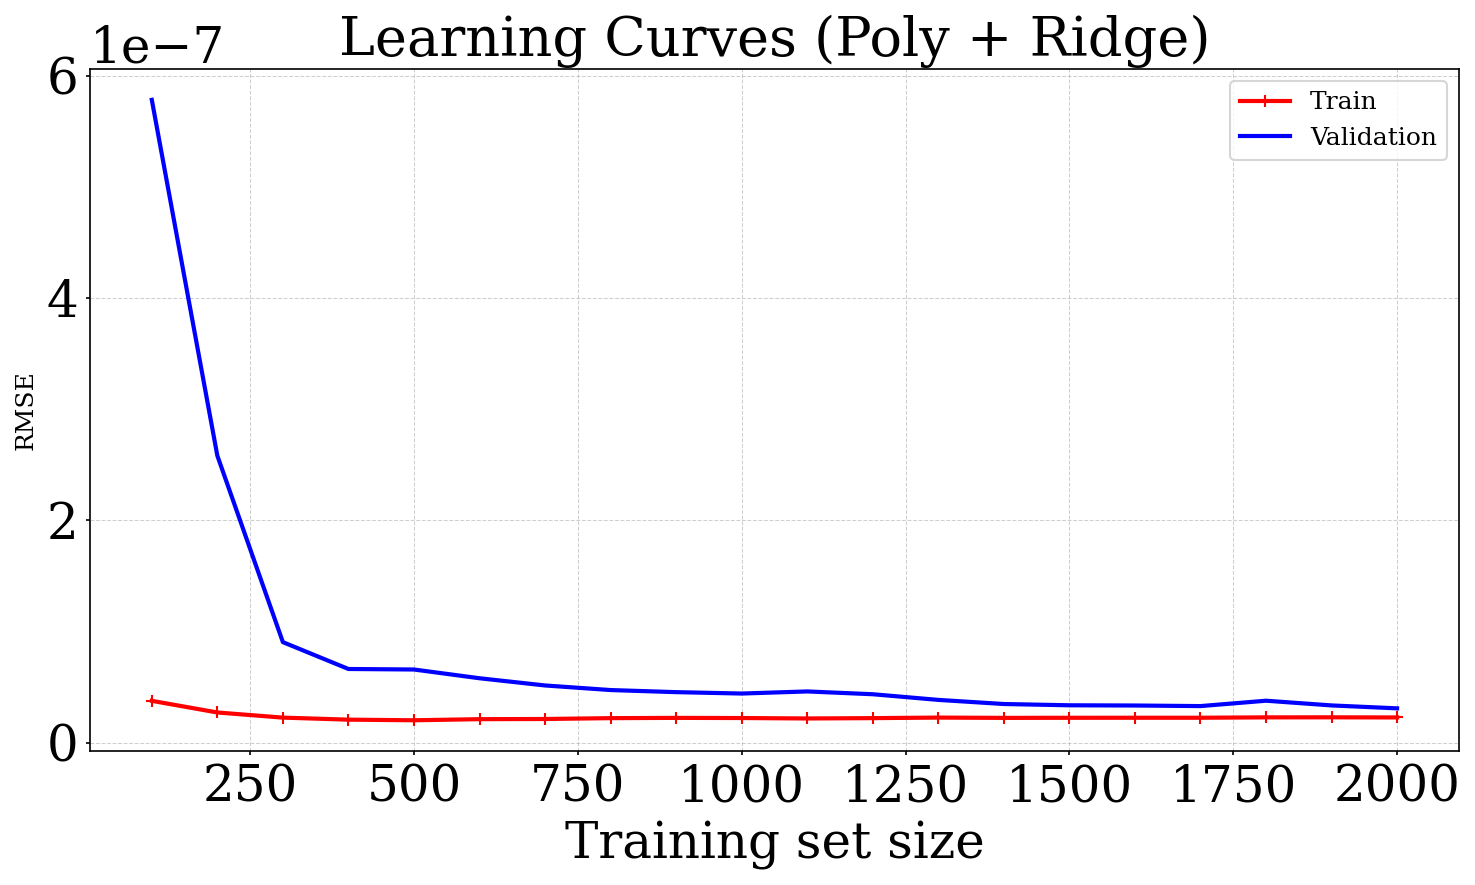

In [ ]:
def plot_learning_curves_poly_cv(X, y, scaler_X, grado, alpha, cv):
    # 1. Usa solo el 80% de los datos para entrenamiento y validación
    X_sub, _, y_sub, _ = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Tamaños crecientes de entrenamiento
    train_sizes = np.linspace(100, 2000, 20, dtype=int)

    train_errors, val_errors = [], []

    for m in train_sizes:
        X_sample = X_sub[:m]
        y_sample = y_sub[:m]

        # Escalar X
        X_scaled = scaler_X.transform(X_sample)
        y_scaled = y_sample  # y ya está escalado o está en su forma final

        # Validación cruzada manual
        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        train_rmse_fold = []
        val_rmse_fold = []

        for train_idx, val_idx in kf.split(X_scaled):
            X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
            y_train_fold, y_val_fold = y_scaled[train_idx], y_scaled[val_idx]

            model = Pipeline([
                ('poly',  PolynomialFeatures(degree=grado, include_bias=False)),
                ('ridge', Ridge(alpha=alpha))
            ])

            model.fit(X_train_fold, y_train_fold)

            y_train_pred = model.predict(X_train_fold)
            y_val_pred   = model.predict(X_val_fold)

            train_rmse = np.sqrt(mean_squared_error(y_train_fold, y_train_pred))
            val_rmse   = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))

            train_rmse_fold.append(train_rmse)
            val_rmse_fold.append(val_rmse)

        train_errors.append(np.mean(train_rmse_fold))
        val_errors.append(np.mean(val_rmse_fold))

    # 3. Graficar
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    ax.plot(train_sizes, train_errors, "r-+", linewidth=2, label="Train")
    ax.plot(train_sizes, val_errors, "b-", linewidth=2, label="Validation")

    ax.set_title("Learning Curves Ridge", fontsize=size_text + 2)
    ax.set_xlabel("Training set size", fontsize=size_text)
    ax.set_ylabel("RMSE", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

    # Ajuste eje Y si tus datos son del orden 1e-6
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

    plt.tight_layout()
    plt.savefig("learning_curve_poly_cv.png", dpi=400, bbox_inches='tight')
    plt.savefig("learning_curve_poly_cv.pdf", dpi=400, bbox_inches='tight')
    plt.savefig("learning_curve_poly_cv.eps", dpi=400, bbox_inches='tight')
    plt.show()

plot_learning_curves_poly_cv(X, y, scaler_X, grado=8, alpha=0.8, cv=5)

# Heatmap of prediction

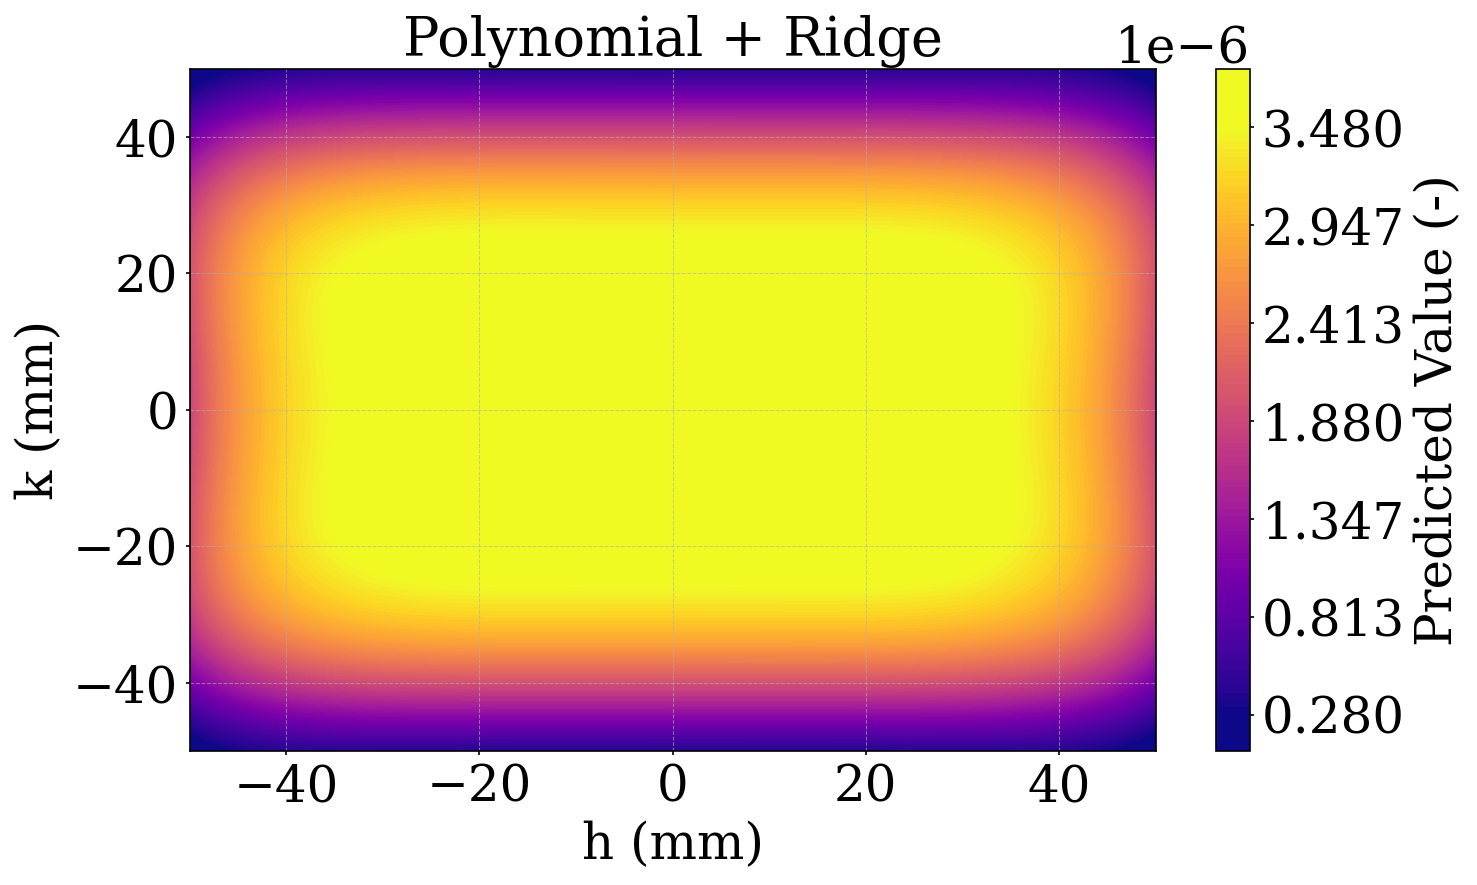

In [ ]:
valor_d = 10  # Valor fijo de la tercera variable
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)

H, K = np.meshgrid(h_vals, k_vals)        # Shape (100, 100)
D = np.full_like(H, valor_d)              # Shape (100, 100)

# 2. Construir X_pred para el modelo
X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)  # Shape (10000, 3)

# 3. Escalar y predecir con tu modelo poly + ridge
X_pred_scaled = scaler_X.transform(X_pred)
F_pred_scaled = model.predict(X_pred_scaled)  # Shape (10000,)

# 4. Desescalar y remodelar para graficar
F_pred = scaler_y.inverse_transform(F_pred_scaled.reshape(-1, 1))  # (10000, 1)
F_pred = F_pred.reshape(H.shape)  # (100, 100)

# 5. Heatmap
vmin = 0.28e-6
vmax = 3.48e-6
ticks = np.linspace(vmin, vmax, 7)

fig, ax = plt.subplots(1, 1, figsize=(w, h), dpi=150)

contour = ax.contourf(H, K, F_pred, levels=100, vmin=vmin, vmax=vmax, cmap='plasma')
cbar = fig.colorbar(contour)
cbar.set_label(label='Predicted Value (-)', size=size_text)
cbar.set_ticks(ticks)

ax.set_title("Polynomial + Ridge", fontsize=size_text + 2)
ax.set_xlabel("h (mm)", fontsize=size_text)
ax.set_ylabel("k (mm)", fontsize=size_text)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig("Heatmap_polypredictions.png", dpi=400, bbox_inches='tight')
plt.savefig("Heatmap_polypredictions.pdf", dpi=400, bbox_inches='tight')
plt.savefig("Heatmap_polypredictions.eps", dpi=400, bbox_inches='tight')
plt.show()